In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import KFold, cross_validate
import shap

In [17]:
df = pd.read_pickle("../Data/df_ready.pkl")
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129,2022,1,1,Saturday
28,2022-01-01,S002,P0009,Groceries,South,131,131,260,64.84,10,Cloudy,0,68.68,Winter,0,145,2022,1,1,Saturday
48,2022-01-01,S003,P0009,Groceries,East,226,96,0,56.32,5,Sunny,0,66.33,Winter,0,126,2022,1,1,Saturday
68,2022-01-01,S004,P0009,Clothing,West,206,106,299,110.47,5,Snowy,0,122.04,Winter,0,98,2022,1,1,Saturday
88,2022-01-01,S005,P0009,Groceries,North,270,59,268,94.75,0,Snowy,0,112.34,Winter,0,94,2022,1,1,Saturday


In [18]:
df.dtypes

date                  datetime64[ns]
store_id                    category
product_id                    object
category                    category
region                      category
inventory_level                int64
units_sold                     int64
units_ordered                  int64
price                        float64
discount                       int64
weather_condition           category
is_promotion                category
competitor_pricing           float64
seasonality                 category
is_epidemic                 category
demand                         int64
year                           int32
month                          int32
day                            int32
day_of_week                 category
dtype: object

In [19]:
# Drop Columns
# store_id, product_id, date: identificadores/timestamp sin poder predictivo directo.
# units_sold, units_ordered: correlacionadas casi directamente con demand -> data leakage.
# competitor_pricing e is_promotion SI se mantienen como features: son variables
# exogenas conocidas antes de la venta, no se derivan de la variable objetivo,
# y pueden aportar señal predictiva real sobre la demanda.
df = df.drop(columns=["store_id", "product_id", "units_sold", "units_ordered", "date", "competitor_pricing", "is_promotion"])

In [20]:
X = pd.get_dummies(df.drop(columns=["demand"]), drop_first=True)
y = df["demand"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [21]:
pipelines = {
    "Baseline (Media)": Pipeline([
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Regresión Lineal + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("model", XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
}

print(f"Modelos de regresión a comparar: {len(pipelines)}")
for name in pipelines:
    print(f"  - {name}")

Modelos de regresión a comparar: 5
  - Baseline (Media)
  - Regresión Lineal + StandardScaler
  - Decision Tree
  - Random Forest
  - XGBoost


In [22]:
cv = TimeSeriesSplit(n_splits=5)
cv_rows = []

scoring_metrics = [
    "neg_mean_absolute_error",
    "neg_mean_absolute_percentage_error",
    "neg_root_mean_squared_error",
    "r2"
]

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1)
    cv_rows.append({
        "Modelo": name,
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "MAPE": -scores["test_neg_mean_absolute_percentage_error"].mean(),
        "RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
        "R2": scores["test_r2"].mean()
    })

df_cv = pd.DataFrame(cv_rows).sort_values("MAE", ascending=True)
df_cv.round({"MAE": 2, "MAPE": 4, "RMSE": 2, "R2": 4})

print("CV Results con TimeSeriesSplit:")
display(df_cv)

CV Results con TimeSeriesSplit:


,Modelo,MAE,MAPE,RMSE,R2
4,XGBoost,10.262050,0.127392,13.734223,0.883769
3,Random Forest,10.580527,0.128090,14.119581,0.874894
1,Regresión Lineal + StandardScaler,11.685087,0.130556,14.797415,0.871714
2,Decision Tree,13.268410,0.153014,18.661400,0.782391
0,Baseline (Media),34.237248,0.430161,42.234946,-0.046527


In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_squared_error,
    r2_score
)
rows = []
for name, pipe in pipelines.items():
    X_tr, X_te = X_train, X_test
    pipe.fit(X_tr, y_train)
    y_p = pipe.predict(X_te)

    rows.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, y_p),
        "MAPE": mean_absolute_percentage_error(y_test, y_p),
        "RMSE": root_mean_squared_error(y_test, y_p),
        "R2": r2_score(y_test, y_p)
    })

df_compare = pd.DataFrame(rows).sort_values("MAE", ascending=True)
df_compare.round({"MAE": 2, "MAPE": 4, "RMSE": 2, "R2": 4})

,Modelo,MAE,MAPE,RMSE,R2
3,Random Forest,8.36,0.0875,9.87,0.9449
4,XGBoost,8.75,0.0956,10.82,0.9337
2,Decision Tree,10.21,0.0996,13.64,0.8947
1,Regresión Lineal + StandardScaler,10.93,0.1225,13.49,0.8971
0,Baseline (Media),34.59,0.4092,42.05,-0.0008


In [24]:
from sklearn.model_selection import RandomizedSearchCV

cv_opt = TimeSeriesSplit(n_splits=5)

# Espacio de busqueda ampliado. El espacio anterior coincidia exactamente con
# los valores por defecto de sklearn, por lo que la busqueda no exploraba
# alternativas reales. Aqui se agregan valores mas chicos y mas grandes.
param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 8, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 6, 8]
}

rf_search = RandomizedSearchCV(
    estimator=pipelines["Random Forest"],
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=cv_opt,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Mejores parametros (Random Forest):")
print(rf_search.best_params_)
print("\nMejor MAE en validacion (Random Forest):")
print(-rf_search.best_score_)

# XGBoost quedo primero en la validacion cruzada (Celda 6), asi que tambien
# se optimiza, para poder comparar de forma justa antes de elegir el modelo final.
param_dist_xgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=pipelines["XGBoost"],
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=cv_opt,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("\nMejores parametros (XGBoost):")
print(xgb_search.best_params_)
print("\nMejor MAE en validacion (XGBoost):")
print(-xgb_search.best_score_)

Mejores parametros (Random Forest):
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 15}

Mejor MAE en validacion (Random Forest):
10.574004893720762

Mejores parametros (XGBoost):
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}

Mejor MAE en validacion (XGBoost):
9.669086837768555


In [31]:
rf_optimizado = rf_search.best_estimator_
xgb_optimizado = xgb_search.best_estimator_

y_pred_rf_opt = rf_optimizado.predict(X_test)
y_pred_xgb_opt = xgb_optimizado.predict(X_test)

rf_original = df_compare[df_compare["Modelo"] == "Random Forest"].copy()
rf_original["Modelo"] = "Random Forest original"


rf_opt = pd.DataFrame([{
    "Modelo": "Random Forest optimizado",
    "MAE": mean_absolute_error(y_test, y_pred_rf_opt),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_rf_opt),
    "RMSE": root_mean_squared_error(y_test, y_pred_rf_opt),
    "R2": r2_score(y_test, y_pred_rf_opt)
}])

xgb_original = df_compare[df_compare["Modelo"] == "XGBoost"].copy()
xgb_original["Modelo"] = "XGBoost original"


xgb_opt = pd.DataFrame([{
    "Modelo": "XGBoost optimizado",
    "MAE": mean_absolute_error(y_test, y_pred_xgb_opt),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_xgb_opt),
    "RMSE": root_mean_squared_error(y_test, y_pred_xgb_opt),
    "R2": r2_score(y_test, y_pred_xgb_opt)
}])

df_modelos_comparacion = pd.concat(
    [rf_original, rf_opt, xgb_original, xgb_opt],
    ignore_index=True
)

display(df_modelos_comparacion.round({"MAE": 2, "MAPE": 4, "RMSE": 2, "R2": 4}))

# El modelo final se elige de forma explicita segun el menor MAE en test,
# en lugar de asumir de antemano cual modelo gano.
mejor_modelo_nombre = df_modelos_comparacion.iloc[0]["Modelo"]
modelo_final = rf_optimizado if "Random Forest" in mejor_modelo_nombre else xgb_optimizado
y_pred_final = y_pred_rf_opt if "Random Forest" in mejor_modelo_nombre else y_pred_xgb_opt

print(f"\nModelo final seleccionado: {mejor_modelo_nombre}")

,Modelo,MAE,MAPE,RMSE,R2
0,Random Forest original,8.36,0.0875,9.87,0.9449
1,Random Forest optimizado,8.33,0.0874,9.82,0.9454
2,XGBoost original,8.75,0.0956,10.82,0.9337
3,XGBoost optimizado,8.30,0.0896,9.97,0.9438



Modelo final seleccionado: Random Forest original


In [32]:
modelo_rf_final = rf_optimizado.named_steps["model"]

feature_ranking = pd.DataFrame(
    data=modelo_rf_final.feature_importances_.reshape(1, len(X_train.columns)),
    columns=X_train.columns
)

feature_ranking = feature_ranking.T.sort_values(by=0, ascending=False)

display(feature_ranking)

,0
price,0.535268
discount,0.160015
region_West,0.101024
region_North,0.095226
region_South,0.050804
category_Groceries,0.016836
inventory_level,0.010536
day,0.007500
month,0.005204
is_epidemic_1,0.002179


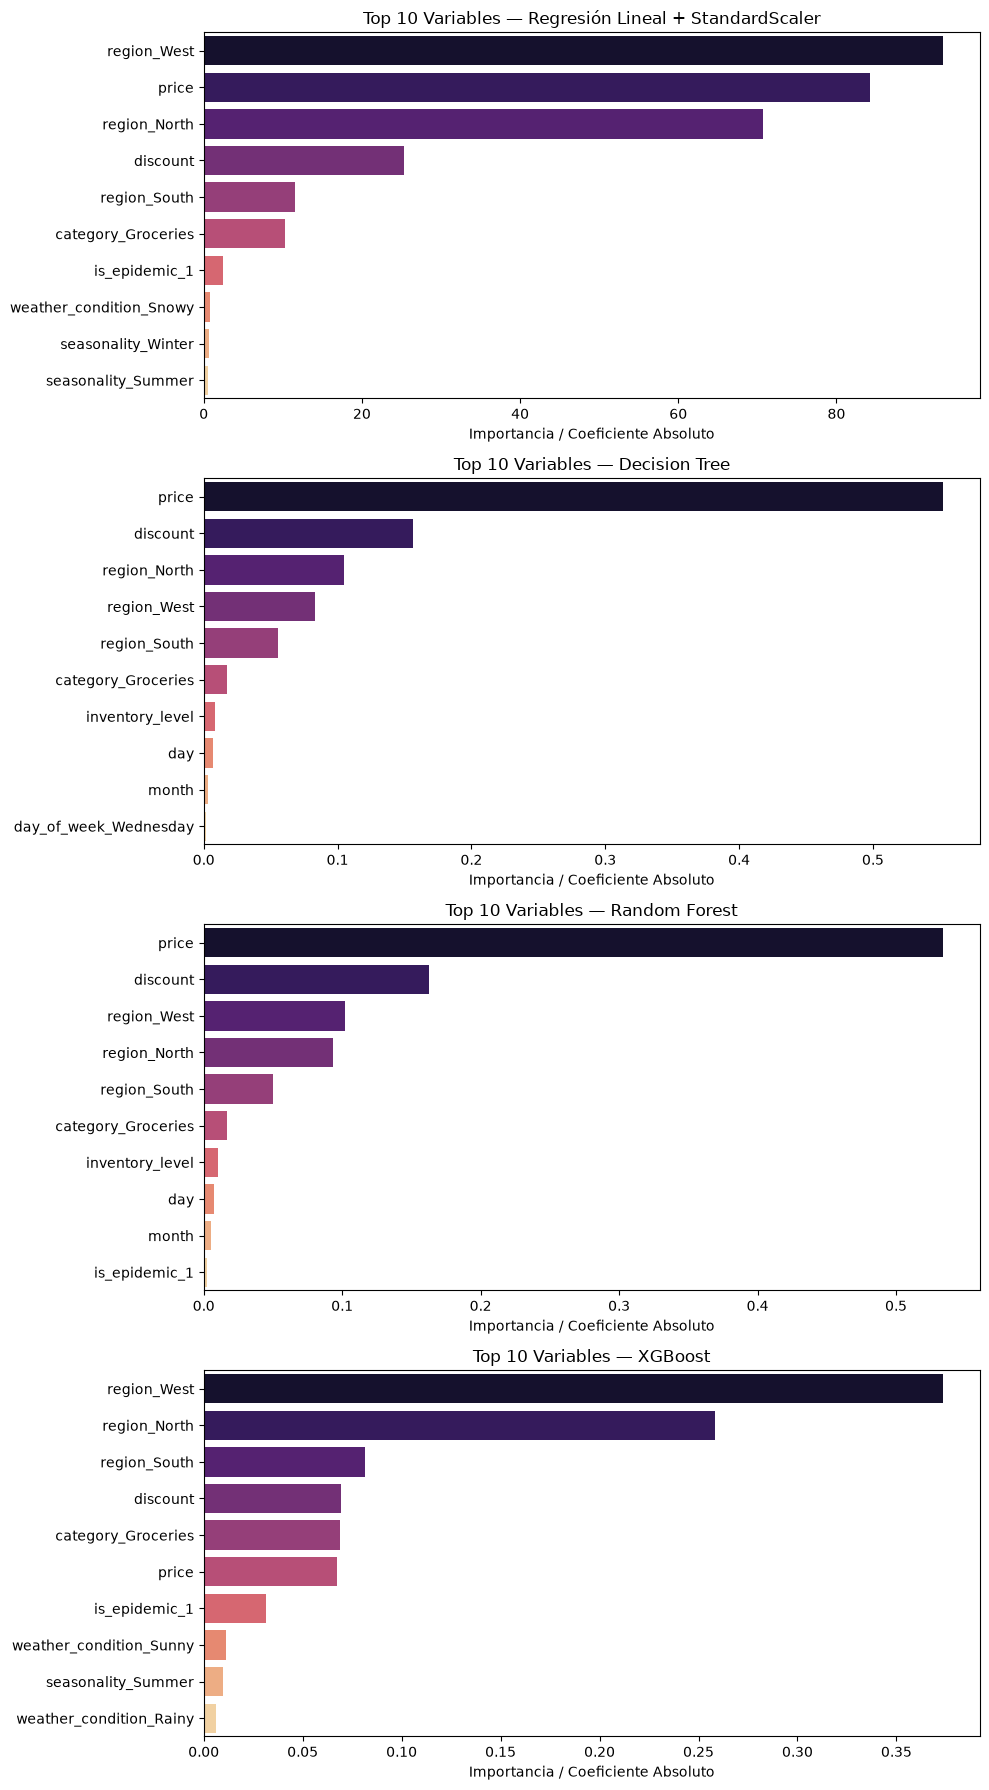

In [34]:
pipelines_vis = {k: v for k, v in pipelines.items() if "Baseline" not in k}
fig, axes = plt.subplots(len(pipelines_vis), 1, figsize=(10, 18))

for i, (name, pipe) in enumerate(pipelines_vis.items()):
    model = pipe.named_steps["model"]
    imps = (
        np.abs(model.coef_)
        if "Regresión Lineal" in name
        else model.feature_importances_
    )

    feat_imp = pd.DataFrame({"Variable": X.columns, "Importancia": imps})
    top10 = feat_imp.sort_values("Importancia", ascending=False).head(10)

    sns.barplot(
        data=top10,
        x="Importancia",
        y="Variable",
        hue="Variable",
        palette="magma",
        legend=False,
        ax=axes[i],
    )
    axes[i].set_title(f"Top 10 Variables — {name}")
    axes[i].set(xlabel="Importancia / Coeficiente Absoluto", ylabel="")

plt.tight_layout()
plt.show()

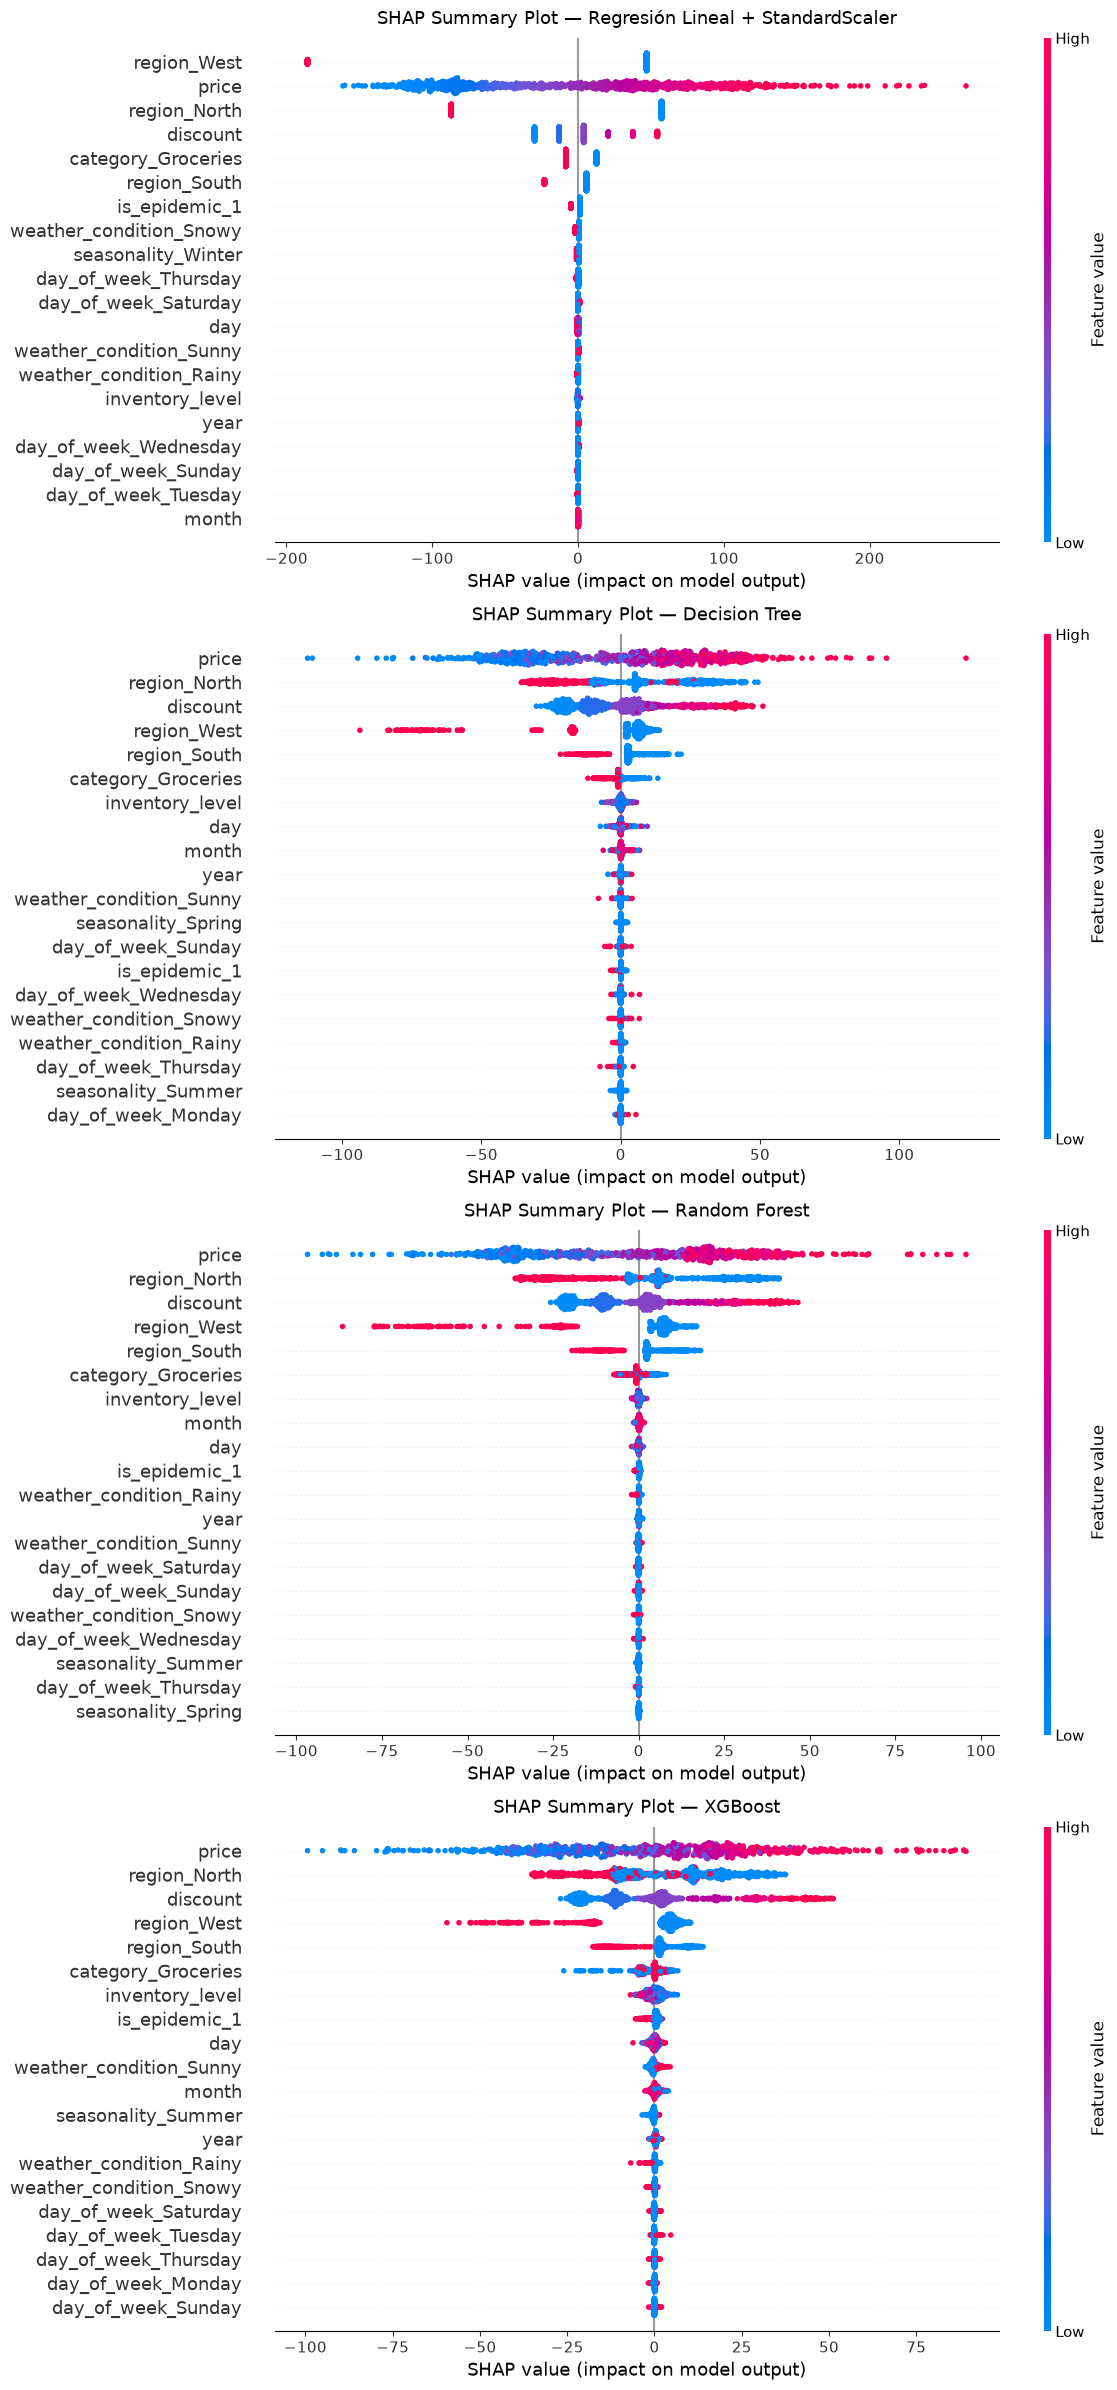

In [28]:
pipelines_vis = {k: v for k, v in pipelines.items() if "Baseline" not in k}
fig, axes = plt.subplots(len(pipelines_vis), 1, figsize=(12, 24))

for i, (name, pipe) in enumerate(pipelines_vis.items()):
    model = pipe.named_steps["model"]

    # Ajuste de datos según el tipo de pipeline
    if "Regresión Lineal" in name:
        # La regresión lineal necesita los datos escalados para calcular los impactos correctamente
        scaler = pipe.named_steps["scaler"]
        X_plot = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
        masker = shap.maskers.Independent(X_plot, max_samples=X_plot.shape[0])
        explainer = shap.LinearExplainer(model, masker)
        shap_vals = explainer.shap_values(X_plot)
    else:
        # Los modelos basados en árboles (TreeExplainer) leen los datos originales directos
        X_plot = X_test
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_plot)

    # Forzar a SHAP a dibujar sobre el eje correspondiente de matplotlib
    plt.sca(axes[i])

    # El método clásico .shap_values garantiza compatibilidad entre versiones de la librería
    shap.summary_plot(shap_vals, X_plot, show=False, plot_size=None)
    axes[i].set_title(f"SHAP Summary Plot — {name}", fontsize=13, pad=10)

plt.tight_layout()
plt.show()

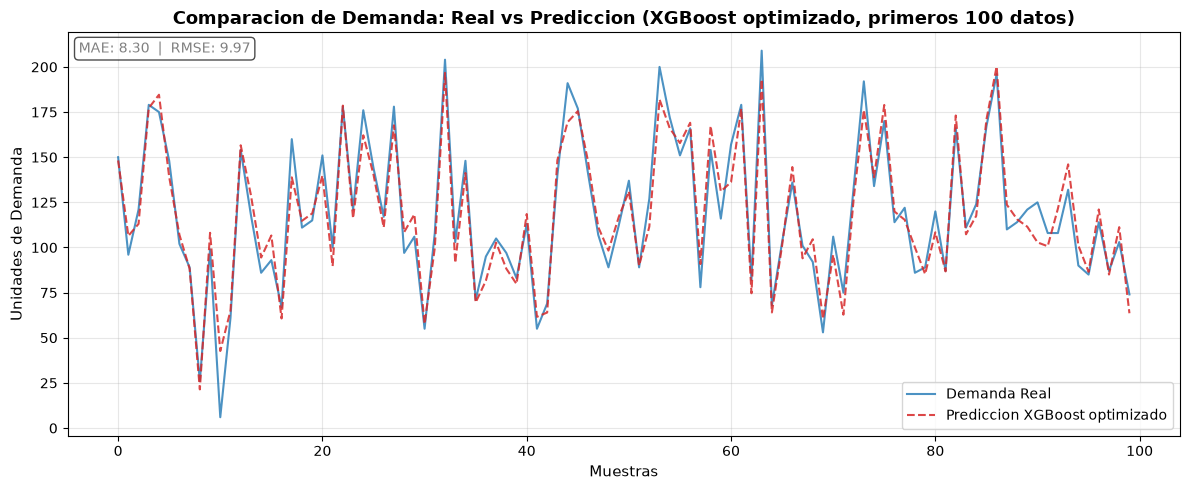

In [29]:
y_pred = y_pred_final

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label="Demanda Real", color="#1f77b4", alpha=0.8, linewidth=1.5)
plt.plot(y_pred[:100], label=f"Prediccion {mejor_modelo_nombre}", color="#d62728",
         linestyle="--", alpha=0.85, linewidth=1.5)

plt.title(f"Comparacion de Demanda: Real vs Prediccion ({mejor_modelo_nombre}, primeros 100 datos)",
          fontsize=13, fontweight="bold")
plt.xlabel("Muestras", fontsize=11)
plt.ylabel("Unidades de Demanda", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.annotate(f"MAE: {mae:.2f}  |  RMSE: {rmse:.2f}",
             xy=(0.01, 0.95), xycoords="axes fraction",
             fontsize=10, color="gray",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()